#### Bibliotecas

In [98]:
# Bibliotecas
import numpy as np
import sys
import warnings
sys.path.append(r'C:\Users\Miyamura\Desktop\GIT_MESTRADO\ppgsi_comparable_mdp_risk\app')

# Problem Definition
# from ppgsi_mdp_risk.env.MultipleSequentialStates import MultipleSequentialStates
# from ppgsi_mdp_risk.services.ErrorMetrics import ErrorMetrics
from ppgsi_configuration_region.residuals.error_metrics import ErrorMetrics
from ppgsi_configuration_region.methods.value_function_factory import ValueFunctionFactory
from ppgsi_configuration_region.viz.mss_plots import MSSPlots

# Including Warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# MSS - Multiple Sequential States Problem
---

Seja $n$ a quantidade de estados $\left\{ s_0, s_1, ..., s_n \right\}$ e cada estado possui uma ação $a_i$ com probabilidade $p_i$ de transicionar para o estado $s_{i+1}$ e probabilidade $(1-p_i)$ de retornar ao estado inicial $s_0$.

## Define Parâmetros
---

In [99]:
# ==================
# Definições Inicias
# ------------------
results = {}

# Custo por Ação
c = 1

# Probabilidade por Ação
p = 0.5
p0 = (1 - p)

# Quantidade de Estados
n = 3

# Numero de simulações
num_simulations = int(1e5)
np.random.seed = 42

# Parametros das metricas

# Parâmetros -------------------
# -- Exponential Utility Method.
# ------------------------------
vl_lambda = 0.01
_epsilon = int(1e-5)
_threshold = 1e4
_alpha = 0.99

EM_EXP = ErrorMetrics(_epsilon)

# Parâmetros -------------------
# -- Visualization
# ------------------------------
range_n = np.arange(1, 11, 1)
range_p = np.arange(0.1, 0.90, 0.05)

## Risk-Neutral
---
Value function formulation for MSS:

$$  $$

Analytical value function formulation for MSS:

$$ V^{n}(s_0) = \frac{c \sum_{i=0}^{n} p^{i}}{p^{n}} $$

In [101]:
rn_method = 'risk_neutral'
rn_obj = ValueFunctionFactory().get_calculator(method=rn_method)
results[rn_method] = {}

# 1.1. Simulacao
results[rn_method]['mss_value_function'], costs = rn_obj.mss_value_function(c, p, n, num_simulations)

# 1.2. Via Formula Analítica
results[rn_method]['mss_analytical_value_function'] = rn_obj.mss_analytical_value_function(c, p, n)

# Print results
print('1. Risk Neutral')
print('1.1. Valor via Simulacao:', results[rn_method]['mss_value_function'])
print('1.2. Valor via Formula Analitica:', results[rn_method]['mss_analytical_value_function'])

1. Risk Neutral
1.1. Valor via Simulacao: 13.99411
1.2. Valor via Formula Analitica: 14.0


## Exponential Utility Method
---

$$
    V^{\pi}(s_0) = e^{-\lambda c(s, \pi(s))} \sum_{s' \in \mathcal{S}} T(s, \pi(s), s') V^{\pi}(s')
$$

In [102]:
# Define metodos ---------------
# -- Exponential Utility Method.
# ------------------------------

# Criando objeto para Exponential Utility Function
exp_method = 'exponential_utility_function'
exp_obj = ValueFunctionFactory().get_calculator(method=exp_method)
results[exp_method] = {}

# MSS > Calcula Funcao Valor
results[exp_method]['mss_value_function'] = exp_obj.mss_value_function(n, p, c, vl_lambda, _threshold, _epsilon)
print('Algoritmo:', results[exp_method]['mss_value_function'])

# MSS > Calcula Formula analítica (se houver)
results[exp_method]['mss_analytical_value_function'] = exp_obj.mss_analytical_value_function(n, p, c, vl_lambda)
print('Analítico:', results[exp_method]['mss_analytical_value_function'])

Algoritmo: {0: 1.1591919355450424, 1: 1.136123630594449, 2: 1.090446087632029, 'sG': 1.0}
Analítico: 1.1591919355450444



              Calculando valores para os seguintes parâmetros:
                p: [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75
 0.8  0.85] | 
                c: 1 | 
                lambda: 0.01 |
              


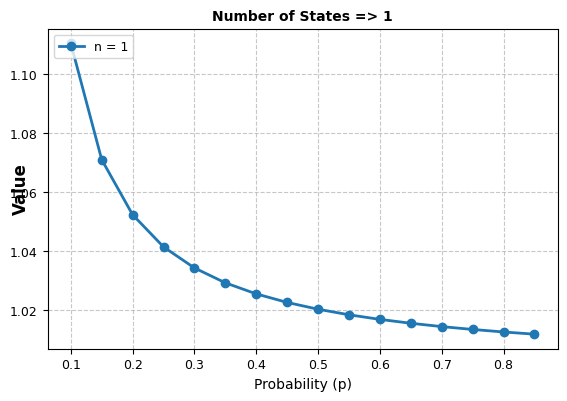

In [103]:
# OSMA > Calcula configuration region para cada probabilidade (p)
results[exp_method]['osma_value_function_range_probability'] = exp_obj.osma_value_function_range_probability(range_p, c, vl_lambda)
MSSPlots().subplots_for_number_of_states(results[exp_method]['osma_value_function_range_probability'], sharey=False)


              Calculando valores para os seguintes parâmetros:
                n: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] | 
                p: [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85] | 
                c: 1 | 
                lambda: 0.01 |
                threshold: 10000 | 
                epsilon: 0.0001 | 
                alpha: 1 |
              


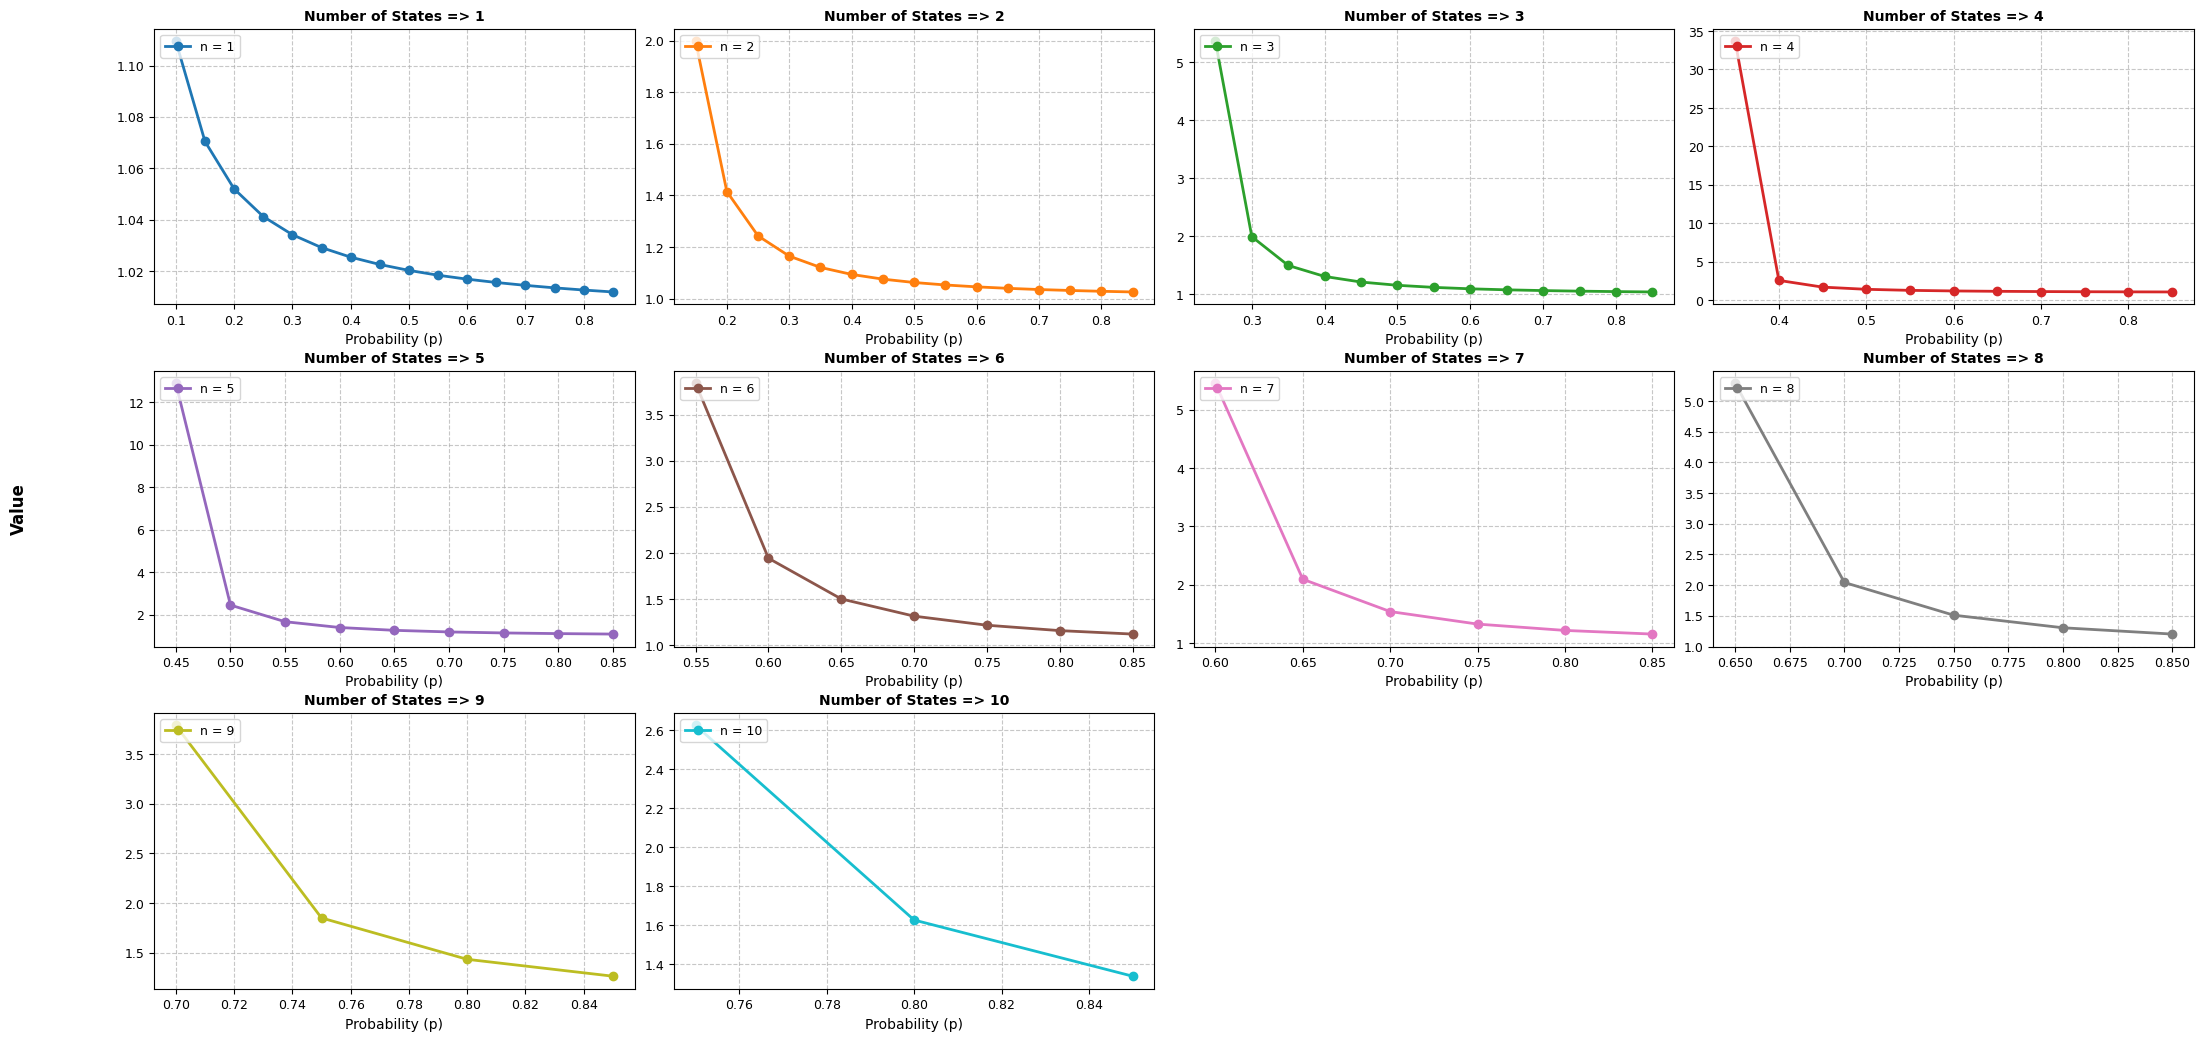

In [113]:
# MSS > Calcula configuration region para cada numero de estado (n) e cada probabilidade (p)
results[exp_method]['mss_value_function_range_probability'] = exp_obj.mss_value_function_range_probability(range_n, range_p, c, vl_lambda, _threshold, _epsilon)
MSSPlots().subplots_for_number_of_states(results[exp_method]['mss_value_function_range_probability'], sharey=False)

### Calculating Lambda-Extreme
---

In [105]:
# Calcual Lambda Extreme
# ----------------------
from ppgsi_configuration_region.methods.exponential_utility_function import LambdaExtreme
_le = LambdaExtreme()

_lambda_extreme_epsilon = 0.00001
_lambda_extreme_beta = 0.0001

In [106]:
# MSS > Calcula lambda extreme para um determinado n e um p
results[exp_method]['find_lambda_extreme'] = _le.find_lambda_extreme(n=3, p=0.5, c=c, vl_lambda=vl_lambda, epsilon=_lambda_extreme_epsilon, beta=_lambda_extreme_beta)
results[exp_method]['find_lambda_extreme']

0.6931371805099451

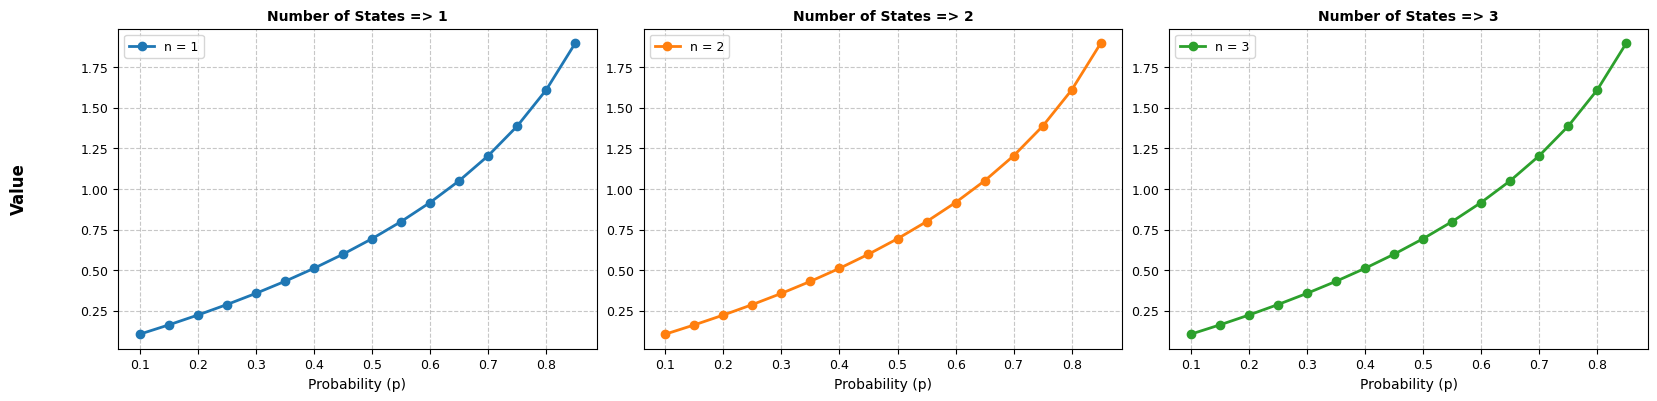

In [107]:
# MSS > Calcula lambda extreme para cada numero de estado (n) e cada probabilidade (p)
results[exp_method]['find_lambda_extreme_range_probability'] = _le.find_lambda_extreme_range_probability(n=[1, 2, 3], p=range_p, c=c, vl_lambda=vl_lambda, epsilon=_lambda_extreme_epsilon, beta=_lambda_extreme_beta)
MSSPlots().subplots_for_number_of_states(results[exp_method]['find_lambda_extreme_range_probability'], sharey=False)

## Piecewise-linear Transformation
---
$$
    O^{\pi}_{\alpha, k}[V](s) = V(s) + \alpha \sum_{s' \in \mathcal{S}} P(s' \mid s, \pi(s)) \mathcal{X}^{(k)}(C(s, \pi(s), s') + \gamma V(s') - V(s))
$$

In [108]:
# Parâmetros -------------------
# -- Exponential Utility Method.
# ------------------------------
k = 0.4
_epsilon = 0.0001
_threshold = int(1e4)

In [109]:
# Criando objeto para Exponential Utility Function
plt_method = 'piecewise_linear_transformation'
plt_obj = ValueFunctionFactory().get_calculator(method=plt_method)
results[plt_method] = {}

# MSS > Value function
results[plt_method]['mss_value_function'], results[plt_method]['iterations'] = plt_obj.mss_value_function(n, p, c, k, _threshold, _epsilon, _verbose=False)
print('Value Function:', results[plt_method]['mss_value_function'])

Value Function: {0: 51.2882649363742, 1: 47.97126529379672, 2: 36.90178545546193, 'sG': 0}



              Calculando valores para os seguintes parâmetros:
                p: [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85] | 
                c: 1 | 
                k: 0.4 |
              


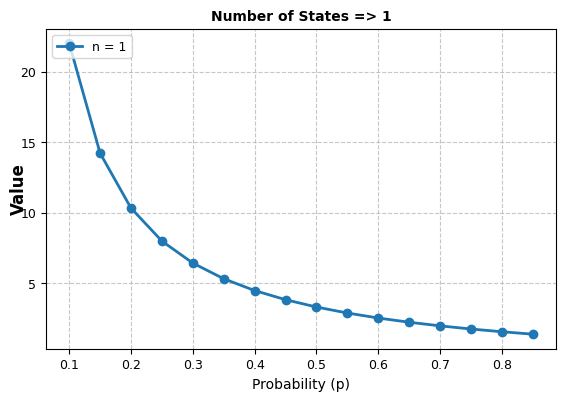

In [110]:
# OSMA > Value function
results[plt_method]['osma_value_function_range_probability'] = plt_obj.osma_value_function_range_probability(range_p, c, k)
MSSPlots().subplots_for_number_of_states(results[plt_method]['osma_value_function_range_probability'], sharey=False)


              Calculando valores para os seguintes parâmetros:
                n: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] | 
                p: [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85] | 
                c: 1 | 
                k: 0.4 |
                threshold: 10000 | 
                epsilon: 0.0001 | 
              


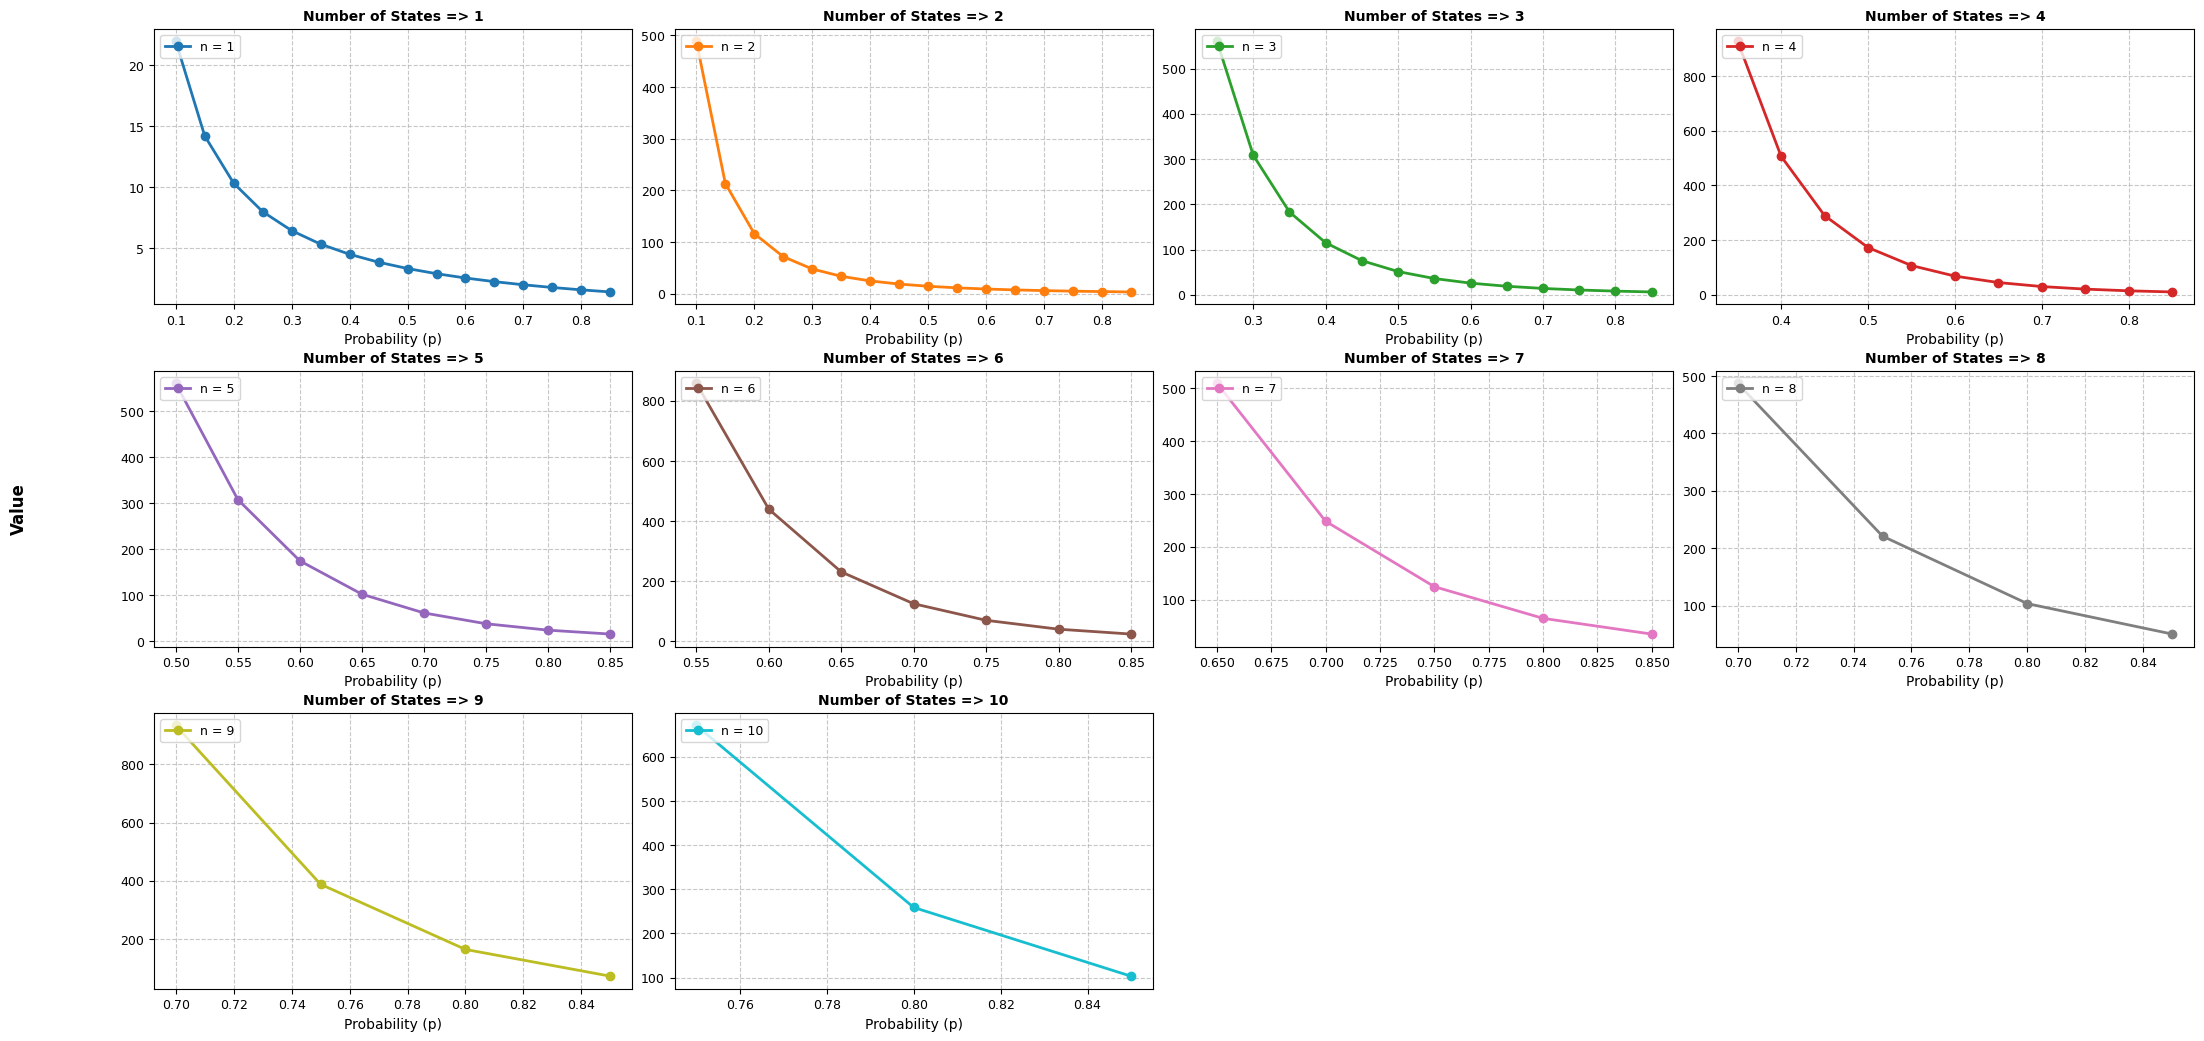

In [111]:
# MSS > Value function
results[plt_method]['mss_value_function_range_probability'] = plt_obj.mss_value_function_range_probability(range_n, range_p, c, k, _threshold, _epsilon, _verbose=False)
MSSPlots().subplots_for_number_of_states(results[plt_method]['mss_value_function_range_probability'], sharey=False)

In [112]:
# # Formula analítica
# def get_value_function_plt(c, p, k, n):
#     a = ((1 - p) * (1 + k)) / (p * (1 - k))
    
#     if n == 1:
#         # return (c * (k - 2 * p * k + 1)) / (p * (1 - k))
#         # return ((1-p)*(1+k)*c)/(p*(1-k)) + c
#         return a * c + c
#     if n == 2:
#         # return (c * (- 2 * p**2 * k - p * k + p + k + 1)) / (p**2 * (1 - k))
#         return (c + c/p) * (1 + a)
#     if n == 3:
#         return (c + c/p + c/p**2) * ((a - 1) / a)

# V_PLT_ANALITICO = get_value_function_plt(c, p, k, n)
# V_PLT_ANALITICO

## Value at Risk

## Conditional Value at Risk

## Mean-variance

## Cumulative Distribution Function